In [1]:
# Import required packages
import numpy as np
import matplotlib.pyplot as plt
from qsopt.core.experimental_parameters import (
    ExperimentalParameters,
    PhysicalConstants,
    SystemDimensions,
    MeasurementProtocol,
    InitialStateConfig,
    InteractionType,
    InitialStateType,
    NoiseConfiguration
)
from qsopt.core.experiment import Experiment
from qsopt.core.circuit import create_ry_circuit
from qsopt.utils import plot_sweep_results, plot_time_evolution

1. **Single Qubit**: Evolution over time and chi-gamma parameter sweep
2. **Two Uncoupled Qubits**: Final state probabilities P(00), P(01), P(10), P(11) vs chi-gamma
3. **Two Coupled Qubits**: Effects of qubit-qubit interaction on final state distributions

## Two Qubits

Now we move to two-qubit experiments.
We'll plot all four final state probabilities: P(00), P(01), P(10), P(11).

In [2]:
phys_const_2q = PhysicalConstants(
    n_qubits=2,
    chi=[40.0, 40.0],  # Equal dispersive coupling for both qubits
    photon_cavity_coupling=10.0,  # gamma
    inverse_pulse_width=1.0,
    qubit_interactions=[]  # No qubit-qubit coupling (chi12=0)
)

sys_dims_2q = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=[2, 2]  # Two qubits, each with 2 levels
)

meas_protocol_2q = MeasurementProtocol(
    measurement_times=[-5, 5],
)

initial_state_2q = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

exp_params_2q = ExperimentalParameters(
    physical_constants=phys_const_2q,
    system_dims=sys_dims_2q,
    measurement=meas_protocol_2q,
    initial_state=initial_state_2q
)

# Create circuits for two qubits (RY rotations for each qubit)
# theta_values = [theta_q1_init, theta_q2_init] for initial circuit
# theta_values = [theta_q1_final, theta_q2_final] for final circuit
initial_circuit_2q = create_ry_circuit(n_qubits=2, theta_values=[np.pi/2, np.pi/2])
final_circuit_2q = create_ry_circuit(n_qubits=2, theta_values=[-np.pi/2, -np.pi/2])

# Create experiment with default detector (1-P(00))
exp_2q_uncoupled = Experiment(exp_params_2q, initial_circuit_2q, final_circuit_2q)


We now sweep over chi and gamma to see all four probability maps.

In [3]:
results_2q_sweep = exp_2q_uncoupled.sweep_chi_gamma(
    chi_interval=[0.1, 40.0],
    gamma_interval=[0.1, 40.0],
    resolution_chi=10,
    resolution_gamma=10,
    chi_scale='linear',
    gamma_scale='linear',
    batch_size=1,
    verbose=True
)

Computing χ-γ parameter sweep...
  Resolution: 10×10 = 100 points
  χ range: [0.10, 40.00] (linear scale)
  γ range: [0.10, 40.00] (linear scale)
  Progress: 10.0% | Elapsed: 45.3s
  Progress: 20.0% | Elapsed: 79.9s
  Progress: 30.0% | Elapsed: 120.2s
  Progress: 40.0% | Elapsed: 165.2s
  Progress: 50.0% | Elapsed: 215.5s
  Progress: 60.0% | Elapsed: 266.4s
  Progress: 70.0% | Elapsed: 317.9s
  Progress: 80.0% | Elapsed: 375.8s
  Progress: 90.0% | Elapsed: 439.2s
  Progress: 100.0% | Elapsed: 502.8s
Sweep completed in 502.8s
  Max contrast: 0.996904
  Optimal χ: 40.000
  Optimal γ: 31.133


Sweep results plot saved to: two_uncoupled_qubits_probability_maps.png


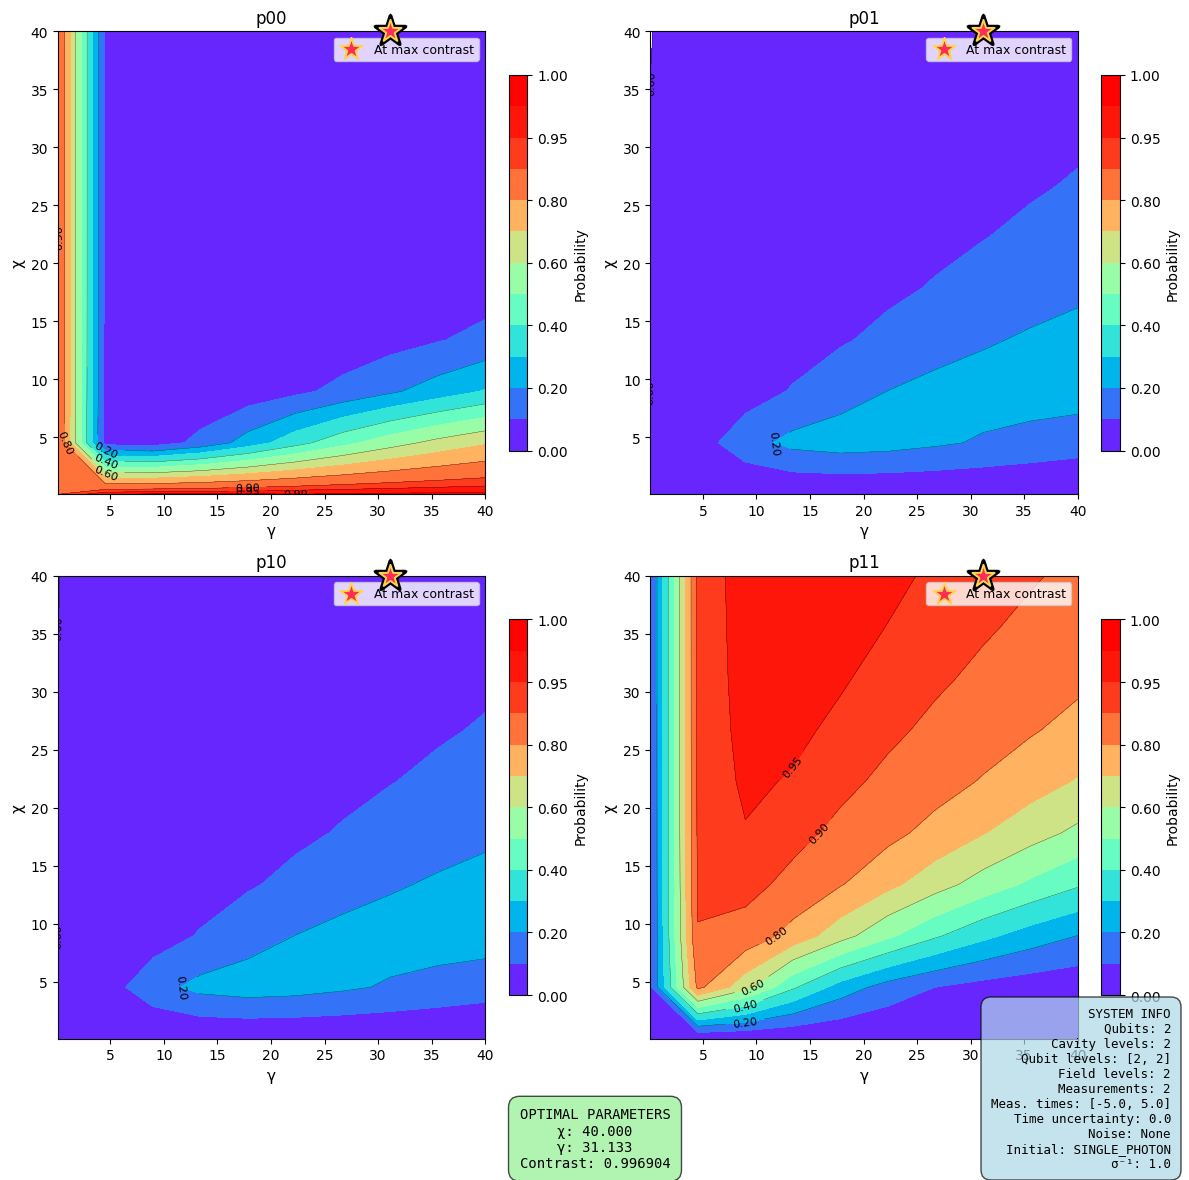

In [ ]:
# Use unified plot_sweep_results to plot all four probability maps in 2x2 grid
plot_sweep_results(
    results_2q_sweep,
    results_to_plot=['p00', 'p01', 'p10', 'p11'],
    figsize=(12, 12),
    save_path='results/two_uncoupled_qubits_probability_maps.png'
)
plt.show()

Sweep results plot saved to: two_uncoupled_qubits_contrast_detection_maps.png


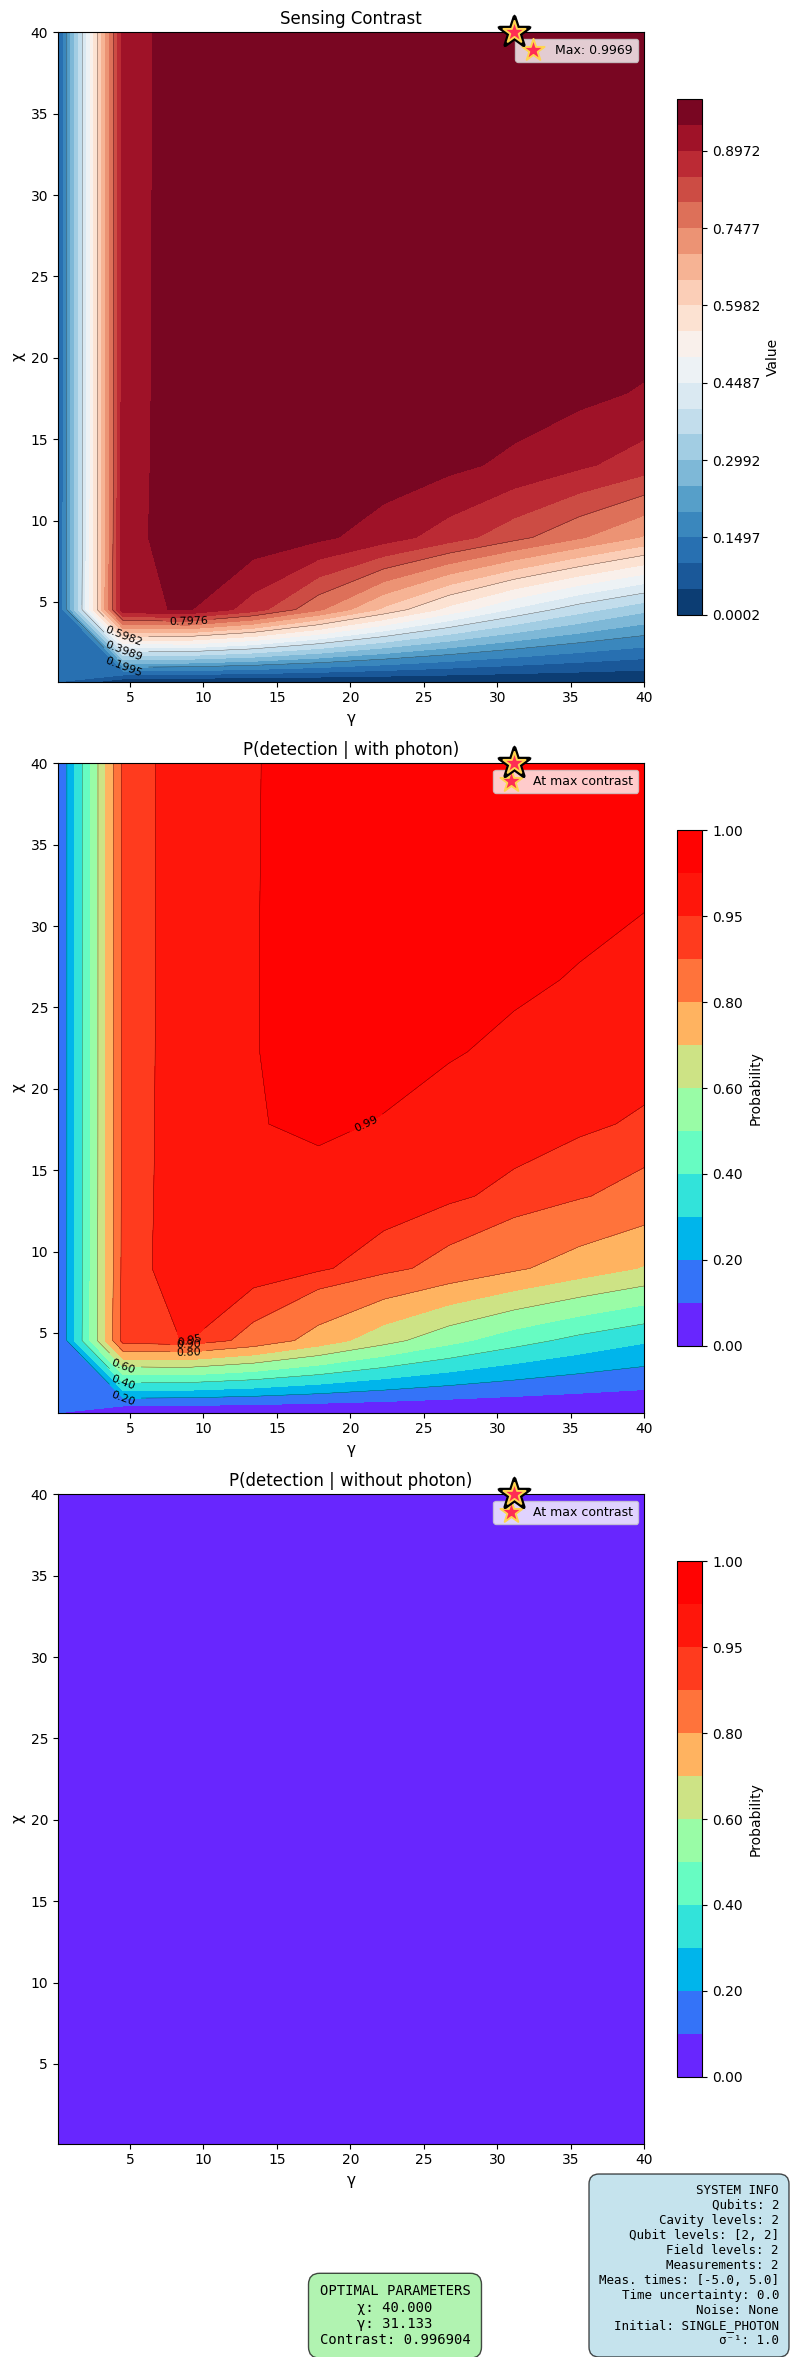

In [5]:
# Plot contrast map and detection maps with optimal point marked
plot_sweep_results(
    results_2q_sweep,
    results_to_plot=['contrast_map', 'detection_map', 'detection_without_map'],
    mark_optimal=True,
    save_path='two_uncoupled_qubits_contrast_detection_maps.png'
)
plt.show()

## Asymmetry Sweeps

In [6]:
# Import the asymmetry sweep functions
from qsopt.utils import compute_asymmetry_coupling_sweep, compute_asymmetry_gamma_sweep

# Asymmetry-Coupling Sweep: Δχ/γ vs χ₁₂/γ
# We fix γ=10 and vary the asymmetry and qubit-qubit coupling
results_asymmetry_coupling = compute_asymmetry_coupling_sweep(
    exp_2q_uncoupled,
    asymmetry_interval=[-8.0, 8.0],
    coupling_interval=[0.0, 10.0],
    resolution_asymmetry=30,
    resolution_coupling=30,
    chi_mean_factor=10.0,  # χ_mean = 10 * γ = 100
    gamma=10.0,
    verbose=True
)

ImportError: cannot import name 'compute_asymmetry_coupling_sweep' from 'qsopt.utils' (D:\Windows Quantum-sensing-QML\src\qsopt\utils\__init__.py)

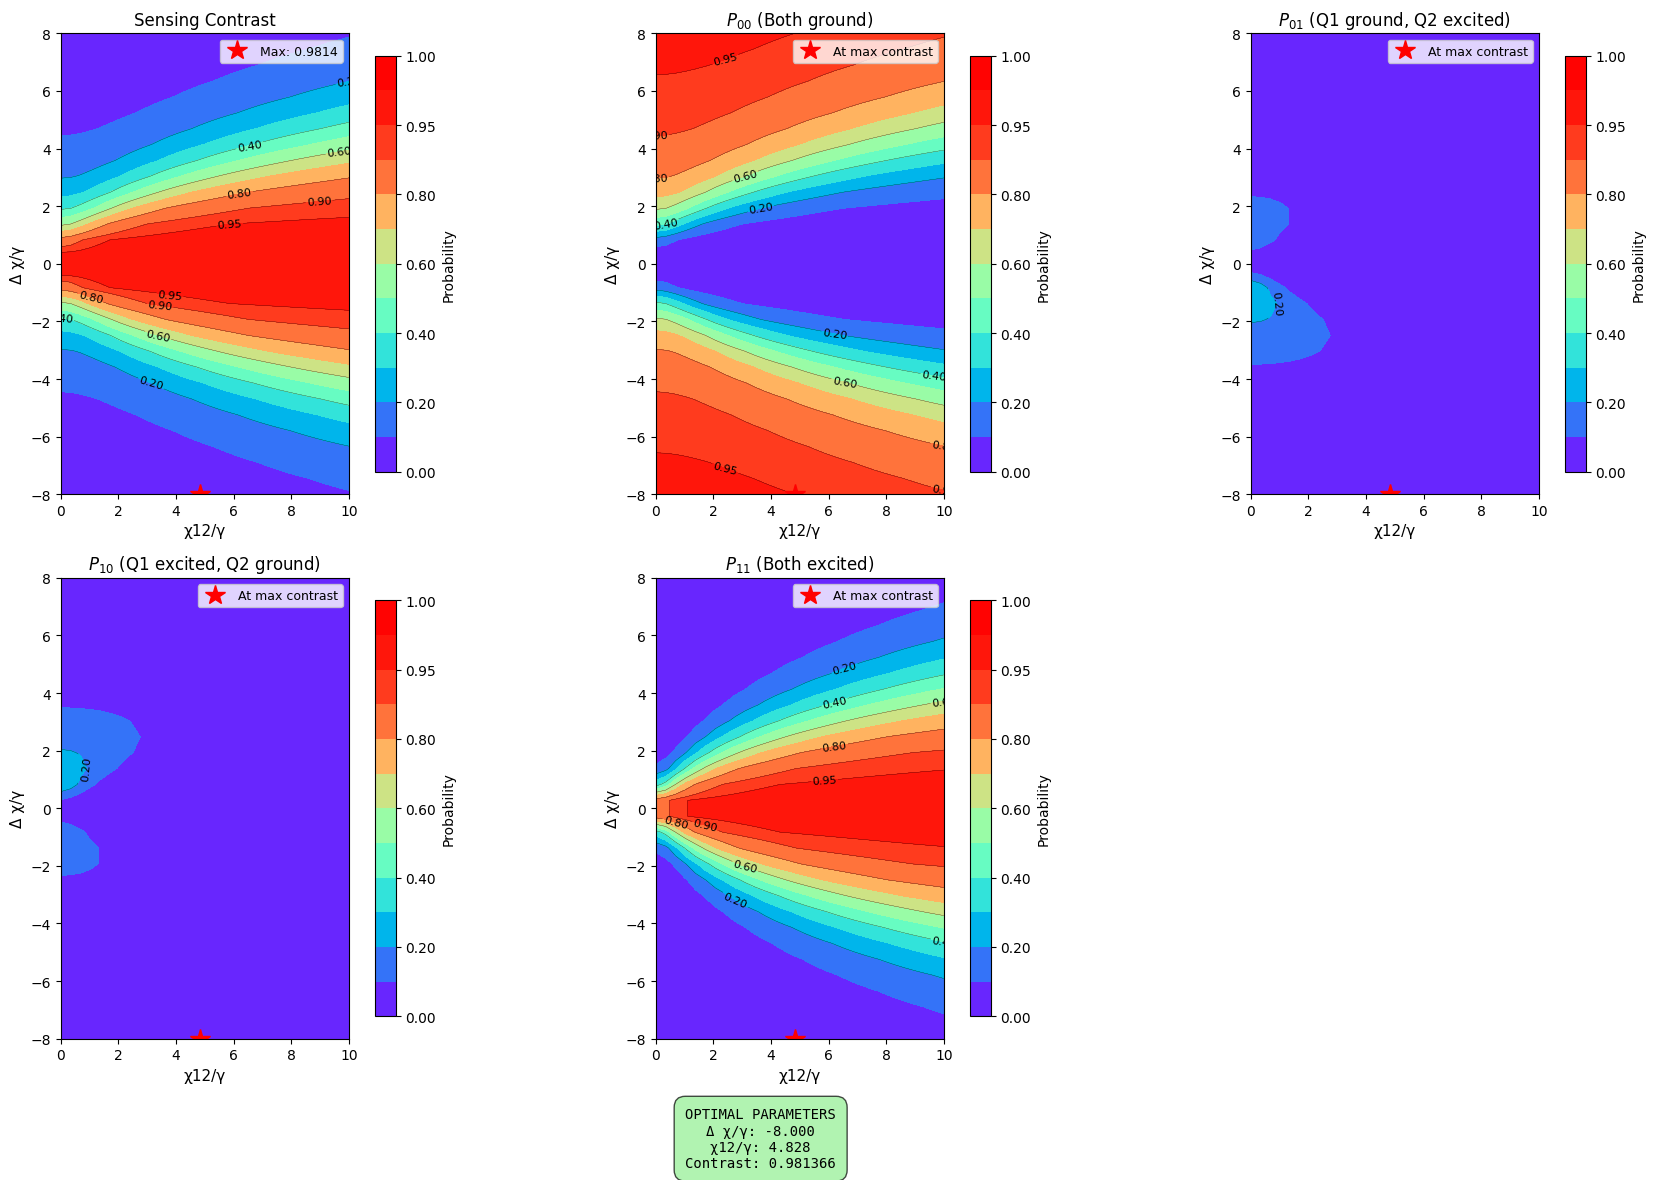

In [ ]:
# Plot asymmetry-coupling sweep results
# Show contrast map and all four probabilities
plot_sweep_results(
    results_asymmetry_coupling,
    results_to_plot=['contrast_map', 'p00', 'p01', 'p10', 'p11', 'detection_map', 'detection_without_map'],
    mark_optimal=True
)
plt.show()

In [ ]:
# Asymmetry-Gamma Sweep: Δχ/γ vs γ
# Now we vary both asymmetry and gamma itself
results_asymmetry_gamma = compute_asymmetry_gamma_sweep(
    exp_2q_uncoupled,
    asymmetry_interval=[-8.0, 8.0],
    gamma_interval=[0.1, 20.0],
    resolution_asymmetry=30,
    resolution_gamma=30,
    chi_mean_factor=10.0,  # χ_mean = 10 * γ (scales with gamma)
    chi12_factor=5.0,       # χ₁₂ = 5 * γ (scales with gamma)
    verbose=True
)

Computing asymmetry-gamma parameter sweep...
  Resolution: 30×30
  Δχ/γ range: [-8.00, 8.00]
  γ range: [0.10, 20.00]
  χ_mean/γ = 10.0, χ₁₂/γ = 5.0
  Progress: 10.0% | Elapsed: 237.9s
  Progress: 10.0% | Elapsed: 237.9s
  Progress: 20.0% | Elapsed: 478.3s
  Progress: 20.0% | Elapsed: 478.3s
  Progress: 30.0% | Elapsed: 754.1s
  Progress: 30.0% | Elapsed: 754.1s
  Progress: 40.0% | Elapsed: 997.3s
  Progress: 40.0% | Elapsed: 997.3s
  Progress: 50.0% | Elapsed: 1239.4s
  Progress: 50.0% | Elapsed: 1239.4s
  Progress: 60.0% | Elapsed: 1484.0s
  Progress: 60.0% | Elapsed: 1484.0s
  Progress: 70.0% | Elapsed: 1768.5s
  Progress: 70.0% | Elapsed: 1768.5s
  Progress: 80.0% | Elapsed: 2015.9s
  Progress: 80.0% | Elapsed: 2015.9s
  Progress: 90.0% | Elapsed: 2264.0s
  Progress: 90.0% | Elapsed: 2264.0s
  Progress: 100.0% | Elapsed: 2514.7s
✓ Sweep completed in 2514.7s
  Max contrast: 0.994088
  Optimal Δχ/γ: 0.276
  Optimal γ: 20.000
  Progress: 100.0% | Elapsed: 2514.7s
✓ Sweep completed in 

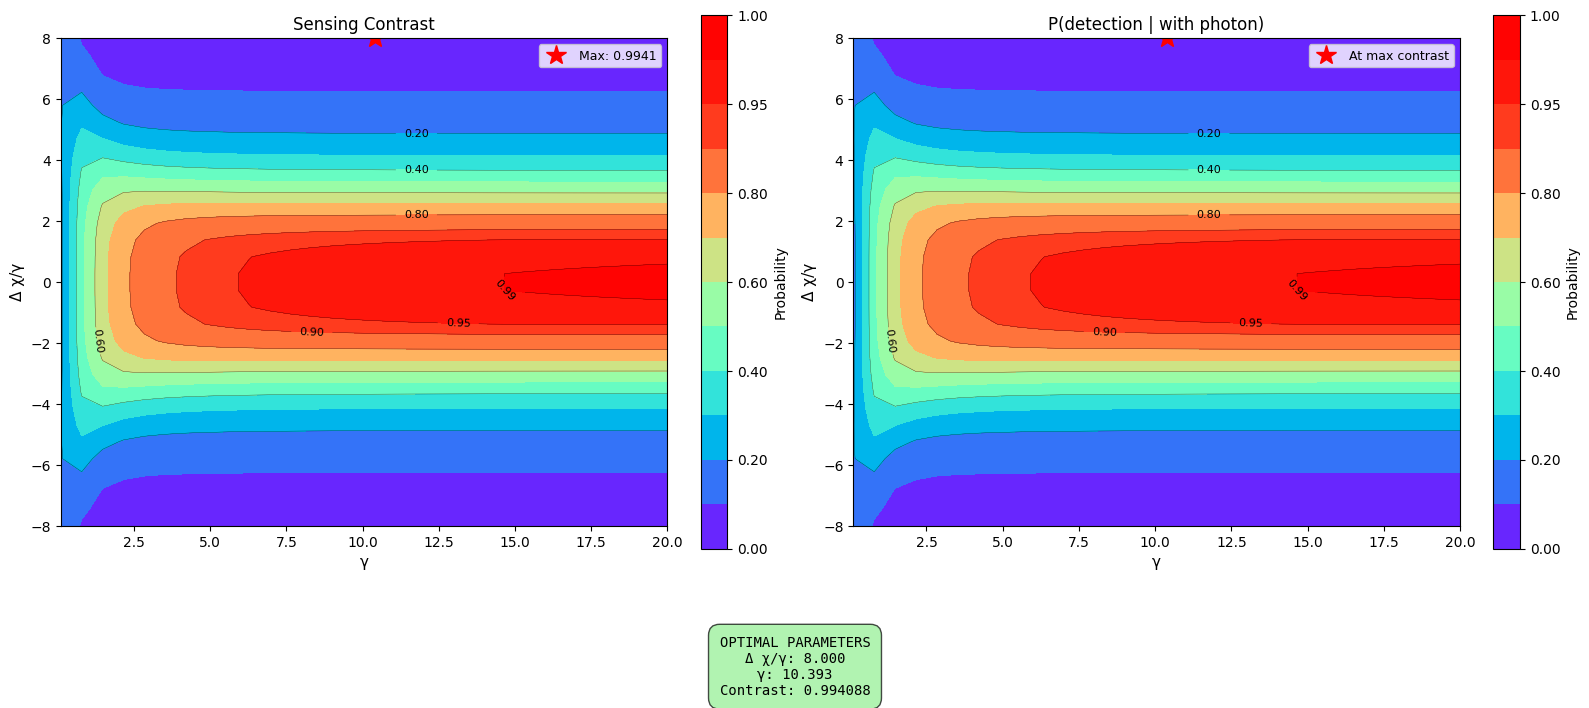

In [ ]:
# Plot asymmetry-gamma sweep results
# Compare with chi-gamma sweep to see how asymmetry affects optimal regions
plot_sweep_results(
    results_asymmetry_gamma,
    results_to_plot=['contrast_map', 'detection_map'],
    mark_optimal=True
)
plt.show()